In [19]:
import numpy as np
import pandas as pd

#Visualization libraries:
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep learning libraries:
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [20]:
#Digit MNIST dataset
(X_train_digit,y_train_digit),(X_test_digit,y_test_digit)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [21]:
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [22]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [23]:
X_test_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [24]:
y_test_digit

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

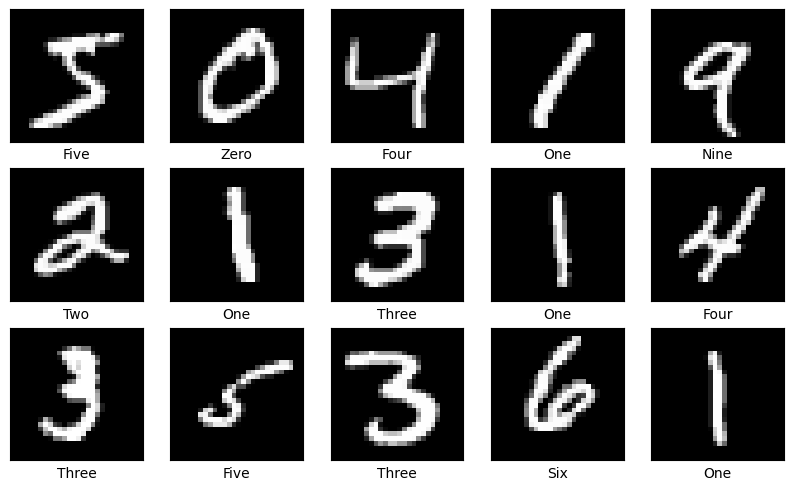

In [25]:
#name the numbers in dataset, like categorical
# image will be converted into matrix and matrix is all about numbers, so we can do calculation.
column_names = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']

#Visualizing the digit
plt.figure(figsize=(10,10)) #figure size 10,10
for i in range(15): # will test for 15 images (range 0-14)
    plt.subplot(5,5,i+1) # 15 rows , 5*3  , i+1 -0,1,2,3,4,5,6,7,8,9
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(column_names[y_train_digit[i]])
plt.show()

In [26]:
X_train_digit.shape 
#shape (rows * column) 
#it's a 3D (60000 for training set & 40000 - test set)
#ex(1 - one dimensional , 1,1 - 2 dimensional, 1,1,1 - 3 dimensional , 1,1,1,1 -4 dimensional))
#below output shows 3 dimensional, in ANN we can process up to 2 dimensional only.
#so, we need to change from 3D to 2D now.
#ANN is 2 dimensional
#60000,28,28 - 28*28 (r*c) / 60000 - count
#we need to flatten 28 * 28 in to row

(60000, 28, 28)

In [27]:
#3D to 2D we use reshape
X_train_digit = X_train_digit.reshape(60000,784)
X_test_digit = X_test_digit.reshape(10000,784)

In [30]:
X_train_digit.shape # 60000 rows and 784 column , now it's changed to 2D

(60000, 784)

In [31]:
X_test_digit.shape

(10000, 784)

In [34]:
y_test_digit.shape # output is in 1 dimensional

(10000,)

In [35]:
y_train_digit.shape # output is in 1 dimensional

(60000,)

In [ ]:
#we are going to covert 1D to categorical (0 to 9 - 10 classify)
#classes - 0 to 9 - 10 classes - onehot encoding like in ML
#if it's 1D - change it to onehot encoding
#ANN - output - onehot enocoding

In [36]:
#encoding digit mnist labels:
y_train_digit=to_categorical(y_train_digit,num_classes=10)
y_test_digit=to_categorical(y_test_digit,num_classes=10)

In [39]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [38]:
y_test_digit

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

In [40]:
#creating base neural n/w
model = keras.Sequential([
    layers.Dense(256, activation='relu',input_shape=(784,)),   #input layer & Hidden layer (256 neurons)
    #layers.dropout(0.3), # we can reduce the input value by another 0.3 for ex: accuracy: 0.78, when reduced it change to 
    #0.48,so we can check for the val_accuracy for improvement.
    #layers.BatchNormalization(),
    layers.Dense(64,activation='relu'),
    #layers.dropout(0.3),
    #layers.BatchNormalization()
    layers.Dense(64,activation='relu'),
    #layers.dropout(0.3),
    #layers.BatchNormalization()
    layers.Dense(10,activation='sigmoid'),
])

    

C:\Anaconda3\envs\AIML\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()
#param_number = output_channel_number(input_channel_number+1)
#256(784+1) = 256*785 = 200960 
#64(256+1) = 64*257 = 16448
#64(64+1) = 64* 65 = 4160
#10(64+1) = 10*65 = 650

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
#compiling the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [43]:
history=model.fit(X_train_digit, y_train_digit, batch_size =100, epochs=10, validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.7878 - loss: 1.5691 - val_accuracy: 0.8971 - val_loss: 0.3277
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9038 - loss: 0.2603 - val_accuracy: 0.9233 - val_loss: 0.2595
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9244 - loss: 0.1693 - val_accuracy: 0.9162 - val_loss: 0.2319
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9297 - loss: 0.1369 - val_accuracy: 0.9015 - val_loss: 0.2040
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9306 - loss: 0.1162 - val_accuracy: 0.8942 - val_loss: 0.1821
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9294 - loss: 0.1098 - val_accuracy: 0.9248 - val_loss: 0.1925
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9291 - loss: 0.0946 - val_accuracy: 0.8969 - val_loss: 0.1792
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9260 - loss: 0.0939 - val_ac

In [44]:
#predicting the labels.digit
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [46]:
y_predict=np.argmax(y_predict, axis=1) #here we get the index of maximum value in the encoded vector
#prediction data

In [47]:
y_predict

array([7, 2, 1, ..., 4, 5, 0], shape=(10000,))

In [52]:
y_test_digit_eval=np.argmax(y_test_digit, axis=1)
#actual data

In [53]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

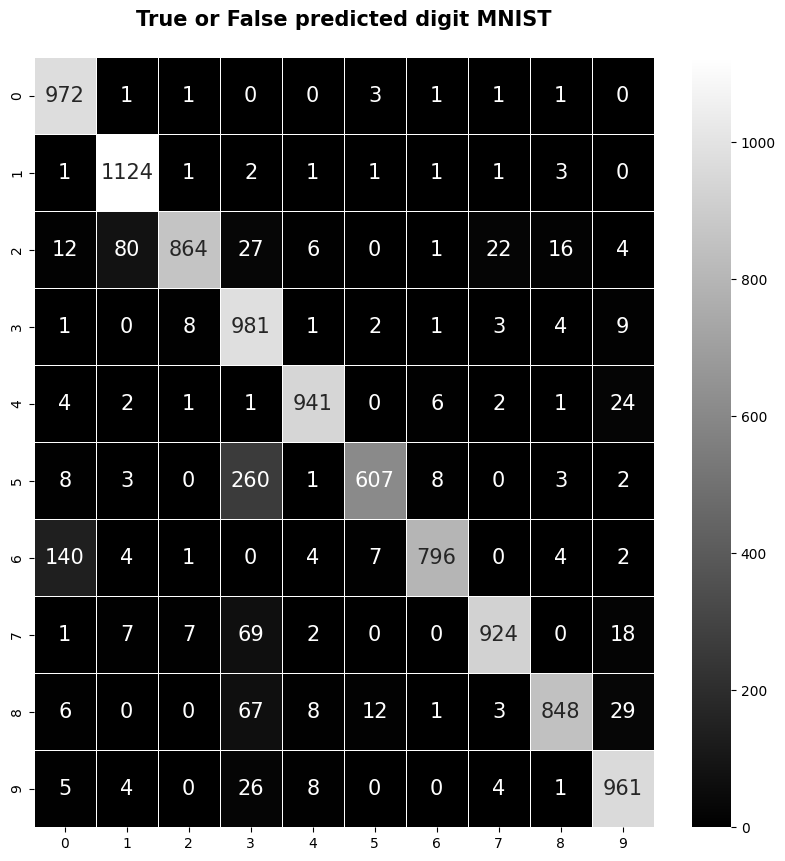

In [55]:
#confusion matrix for Digit mnist
con_mat=confusion_matrix(y_test_digit_eval,y_predict)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidth=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()


In [57]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval,y_predict))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       980
           1       0.92      0.99      0.95      1135
           2       0.98      0.84      0.90      1032
           3       0.68      0.97      0.80      1010
           4       0.97      0.96      0.96       982
           5       0.96      0.68      0.80       892
           6       0.98      0.83      0.90       958
           7       0.96      0.90      0.93      1028
           8       0.96      0.87      0.91       974
           9       0.92      0.95      0.93      1009

    accuracy                           0.90     10000
   macro avg       0.92      0.90      0.90     10000
weighted avg       0.92      0.90      0.90     10000



In [58]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


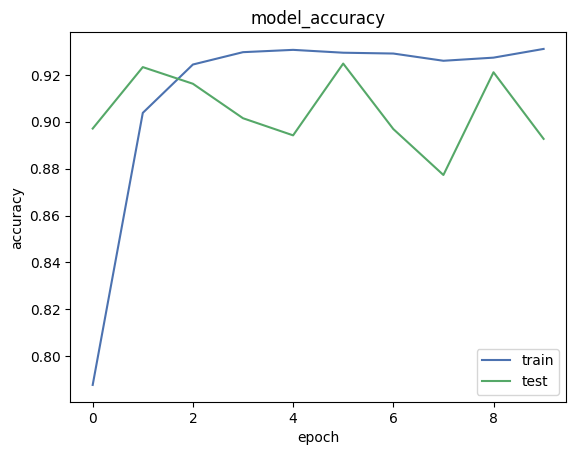

In [59]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.show()

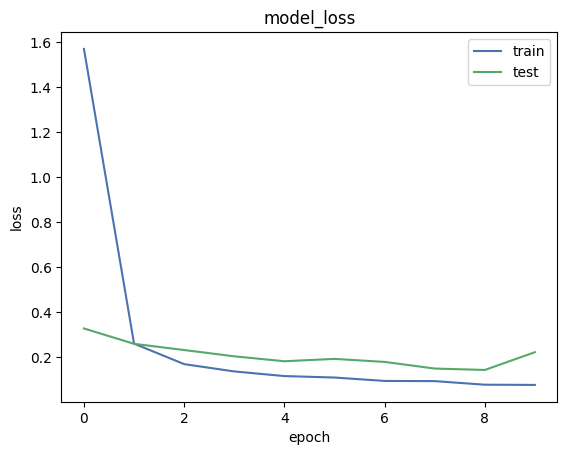

In [60]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='best')
plt.show()

In [61]:
#tf.expand_dims(X_test_digit[0])
y_predict_single= model.predict(X_test_digit[[2]])
y_predicts_single=np.argmax(y_predict_single,axis=1) #here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_digit,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


In [62]:
y_predict_single

array([[9.4589533e-04, 1.0000000e+00, 9.9999976e-01, 8.6096925e-01,
        9.9997348e-01, 7.7368563e-01, 9.9999899e-01, 9.9996293e-01,
        9.9999708e-01, 9.5970803e-01]], dtype=float32)

In [63]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

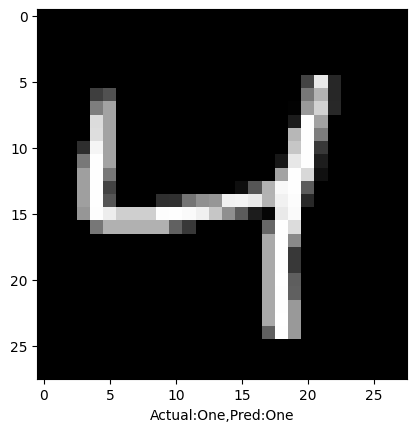

In [71]:
column_names = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']

#Visualizing the digit
plt.imshow(X_train_digit[2].reshape(28,28), cmap='gray')
plt.xlabel('Actual:{},Pred:{}'.format(column_names[np.argmax(y_test_digit[2])],column_names[y_predicts_single[0]]))
plt.show()